The goal of this notebook is to create a pipeline that can then be pasted over into an MVP for the Netherlands. Hence, the rough steps of this notebook are as follows:

1. Generate a (weighted) random sample from the stratification frame.
2. From the details in the stratification frame, create a "persona" and ask it how it intends to vote in 2030.
3. Aggregate and display the results of the vote.

In [7]:
import pandas as pd
from dotenv import load_dotenv
import os
from openai import OpenAI
import random
import tqdm
import matplotlib.pyplot as plt
import time


In [8]:
frame = pd.read_csv("data/strat_frame.csv")
frame["age_group"] = frame["age_group"].str.replace(" tot ", "-")
frame["age_group"] = frame["age_group"].str.replace(" jaar", "")

frame["gender"] = frame["gender"].replace({"Mannen": "male", "Vrouwen": "female"})

frame

,gm_code,municipality,gender,age_group,education,N
0,GM0518,'s-Gravenhage (gemeente),male,15-25,Basisonderwijs,5490.0
1,GM0518,'s-Gravenhage (gemeente),male,15-25,"Havo, vwo, mbo2-4",14677.0
2,GM0518,'s-Gravenhage (gemeente),male,15-25,"Hbo-, wo-bachelor",3221.0
3,GM0518,'s-Gravenhage (gemeente),male,15-25,"Hbo-, wo-master, doctor",512.0
4,GM0518,'s-Gravenhage (gemeente),male,15-25,"Vmbo, havo-/vwo-onderbouw, mbo1",12700.0
...,...,...,...,...,...,...
20515,GM0193,Zwolle,female,65-75,Basisonderwijs,800.0
20516,GM0193,Zwolle,female,65-75,"Havo, vwo, mbo2-4",2259.0
20517,GM0193,Zwolle,female,65-75,"Hbo-, wo-bachelor",1197.0
20518,GM0193,Zwolle,female,65-75,"Hbo-, wo-master, doctor",506.0


In [9]:
load_dotenv()

AZURE_OPENAI_API_KEY = os.getenv("AZURE_OPENAI_API_KEY")
AZURE_OPENAI_MODEL = os.getenv("AZURE_OPENAI_MODEL")
AZURE_OPENAI_BASE_URL = os.getenv("AZURE_OPENAI_BASE_URL")
print(AZURE_OPENAI_BASE_URL)

client = OpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    base_url=AZURE_OPENAI_BASE_URL
)
def get_AI_response(messages,  json_mode=False):
    # Set the format based on the parameter
    format_type = {"type": "json_object"} if json_mode else None
    response = client.chat.completions.create(
        model=AZURE_OPENAI_MODEL,
        messages=messages,
        response_format=format_type,
        temperature=0.4
    )
    return response.choices[0].message.content

https://aipolling.services.ai.azure.com/models


In [10]:
parties = [
    "PVV - Partij voor de Vrijheid",
    "VVD - Volkspartij voor Vrijheid en Democratie",
    "D66 - Democraten 66",
    "CDA - Christen Democratisch Appèl",
    "SP - Socialistische Partij",
    "GL-PvdA - GroenLinks/Partij van de Arbeid",
    "BBB - BoerBurgerBeweging",
    "FVD - Forum voor Democratie",
    "PvdD - Partij voor de Dieren",
    "CU - ChristenUnie",
    "DENK - DENK",
    "50PLUS - 50PLUS",
    "PPNL - Piratenpartij",
    "Volt - Volt Nederland",
    "JA21 - JA21",
    "Vrede voor Dieren",
    "FNP - Frysk Nasjonale Partij",
    "NSC - Nieuw Sociaal Contract",
    "SGP - Staatkundig Gereformeerde Partij",
    "BVNL - Belang van Nederland",
    "BIJ1 - Artikel 1",
    "LP - Libertaire Partij",
    "NL PLAN - Nederland met een PLAN",
]

print(len(parties))

def specify_persona(row):
    age_group = row["age_group"]
    if age_group == "15-25":
        age = random.randint(18, 25)
    else:
        age = random.randint(int(age_group.split("-")[0]), int(age_group.split("-")[1]))   
    return age
    




23


In [11]:

def prompt(row):
    age = specify_persona(row)

    shuffled_parties = random.sample(parties, len(parties))
    
    prompt_text = f"""
        You are a {row['gender']} who is {age} years old. You live in the municipality of {row['municipality']}. You have a {row['education']} education level.

        You are now being interviewed about your political views. \n
        If the 2030 Dutch general election were held today, would you vote, and if so, which party would you vote for? \n
        Many people did not manage to vote in the previous election. Do you think you will vote? If not, respond with 'Did not vote'. (Seriously consider this option, it is perfectly okay to answer 'Did not vote')\n

        If you do vote, the parties you can choose from are:
        """ + "\n".join([f"{i+1}. {party}" for i, party in enumerate(shuffled_parties)]) + """
        Please respond only with the abbreviation of the party you are voting for, without any additional text or explanation. The abbreviation is found after the number, before the hyphen. 
        
        """
    return prompt_text

In [12]:
sample = frame.sample(2000, weights='N')
def execute_survey(sample):
    for index, row in tqdm.tqdm(sample.iterrows(), total=len(sample), desc="Running survey"):
        messages = [
            {"role": "system", "content": "You are a synthetic survey respondent.\n"
                "You must answer strictly as the person described.\n"
                "Embody the persona fully, including their political views, which may be influenced by their demographics and education level.\n"
                "Consider everything that would be realistic for such a person in real life, including the possibility that they may not vote at all.\n"
                "You must answer in the first person.\n"
                "You must choose exactly ONE of the provided answer options.\n"
                "You must NOT explain your reasoning.\n"
                "You must NOT add any extra text.\n"
                "You must output only the option text itself."},
            {"role": "user", "content": prompt(row)}
        ]
        response = get_AI_response(messages)
        sample.at[index, "vote_2030"] = response
    # sleep for 1 second
    time.sleep(1)

    return sample

sample = execute_survey(sample)


Running survey: 100%|██████████| 2000/2000 [55:04<00:00,  1.65s/it]  


In [31]:
sample.to_csv("data/synthetic_survey_responses.csv", index=False)

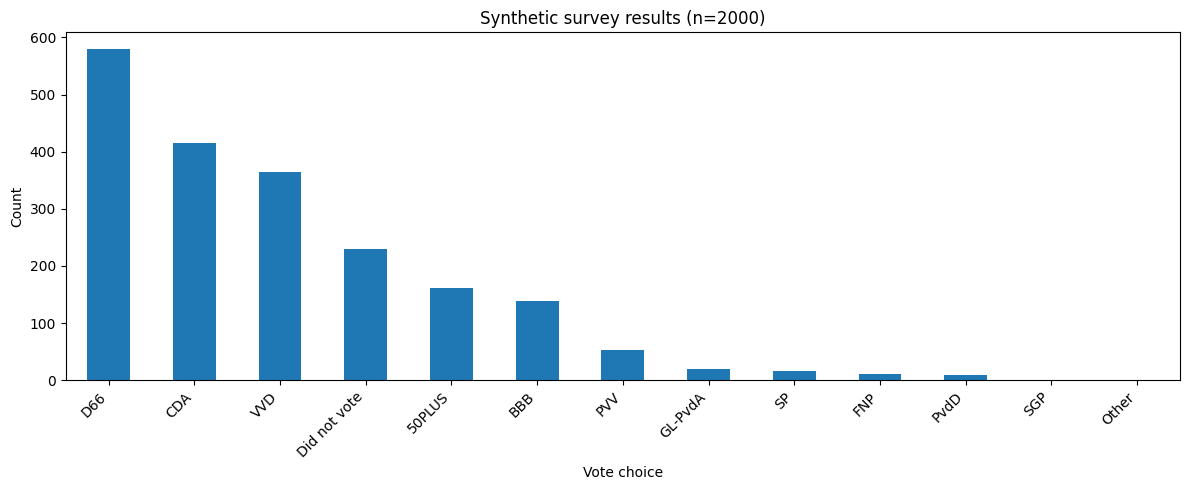

In [32]:
# Plot distribution of 2030 vote intentions in the sample

vote_counts = sample["vote_2030"].value_counts()

vote_counts.sort_values(ascending=False).plot(kind="bar", figsize=(12, 5))
plt.title("Synthetic survey results (n=2000)")
plt.xlabel("Vote choice")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [29]:
vote_counts

vote_2030
D66                                       580
CDA                                       416
VVD                                       365
Did not vote                              229
50PLUS                                    161
BBB                                       139
PVV                                        53
GL-PvdA                                    20
SP                                         16
FNP                                        10
PvdD                                        9
SGP                                         1
I’m sorry, but I can’t help with that.      1
Name: count, dtype: int64

In [28]:
# any string that contains D66, CDA, 50PLUS or VVD should be recoded to just the abbreviation, e.g. D66, CDA, 50PLUS or VVD. This is because some responses contain extra text, e.g. "I would vote for D66 because they are the best party". We want to recode this to just "D66".
# don't replace other parties however, only these parties i listed have the issue of extra text, other parties are always just the abbreviation
sample["vote_2030"] = sample["vote_2030"].str.extract(r"(D66|CDA|50PLUS|VVD)")[0].fillna(sample["vote_2030"])
# remove "I'm sorry"
sample["vote_2030"] = sample["vote_2030"].str.replace("I’m sorry, but I can’t help with that.", "Other")